### Overview

This notebook demonstrates how to use `elastic_models` lib to inference optimized FLUX.1-schnell.

For each model, elastic_models provides a series of optimized models:

- XL: Mathematically equivalent neural network, optimized with our DNN compiler.

- L: Near lossless model, with less than 1% degradation obtained on corresponding benchmarks.

- M: Faster model, with quality degradation less than 1.5%.

- S: The fastest model, with quality degradation less than 2%.

To compare model quality for FLUX.1-schnell we used FID score between outputs of original and compressed models

#### Setup environment

Let's start with installing `elastic_models` and `thestage` libs

In [1]:
!pip install thestage matplotlib pynvml
!pip install 'thestage-elastic-models[nvidia]' --extra-index-url https://thestage.jfrog.io/artifactory/api/pypi/pypi-thestage-ai-production/simple

  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached humanfriendly-10.0-py2.py3-none-any.whl.metadata (9.2 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
  Using cached jmespath-1.1.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached h11-0

Generate thestage access-token. 
See https://docs.thestage.ai/platform/src/thestage-ai-ssh-keys-and-api-tokens.html

Now set up generated token

Generate thestage access-token. 
See https://docs.thestage.ai/platform/src/thestage-ai-ssh-keys-and-api-tokens.html

In [2]:
!echo y | thestage config set --access-token <YOUR_ACCESS_TOKEN>

Do you want to change current token? (y, n) [y]: Configuration updated successfully


In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES']="0"

In [4]:
import torch
from elastic_models.diffusers import DiffusionPipeline
import matplotlib.pyplot as plt

/root/.pyenv/versions/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/root/.pyenv/versions/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Loading model

Below we will load flux schnell pipeline by it's huggingface name.

We set `mode="XL"` to use model variant equivalent to the original, optimized with our DNNs compiler

In [5]:
mode_name = "black-forest-labs/FLUX.1-schnell"
device = torch.device("cuda")
pipeline = DiffusionPipeline.from_pretrained(
    mode_name,
    torch_dtype=torch.bfloat16,
    cache_dir="/mount/huggingface_cache",
    mode="XL"
)
pipeline.to(device)

Fetching elastic checkpoint: 100%|██████████| 62/62 [00:00<00:00, 12133.58it/s]


FluxPipeline {
  "_class_name": "FluxPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "black-forest-labs/FLUX.1-schnell",
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "T5EncoderModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "T5TokenizerFast"
  ],
  "transformer": [
    "diffusers",
    "FluxTransformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

100%|██████████| 4/4 [00:00<00:00, 15.46it/s]


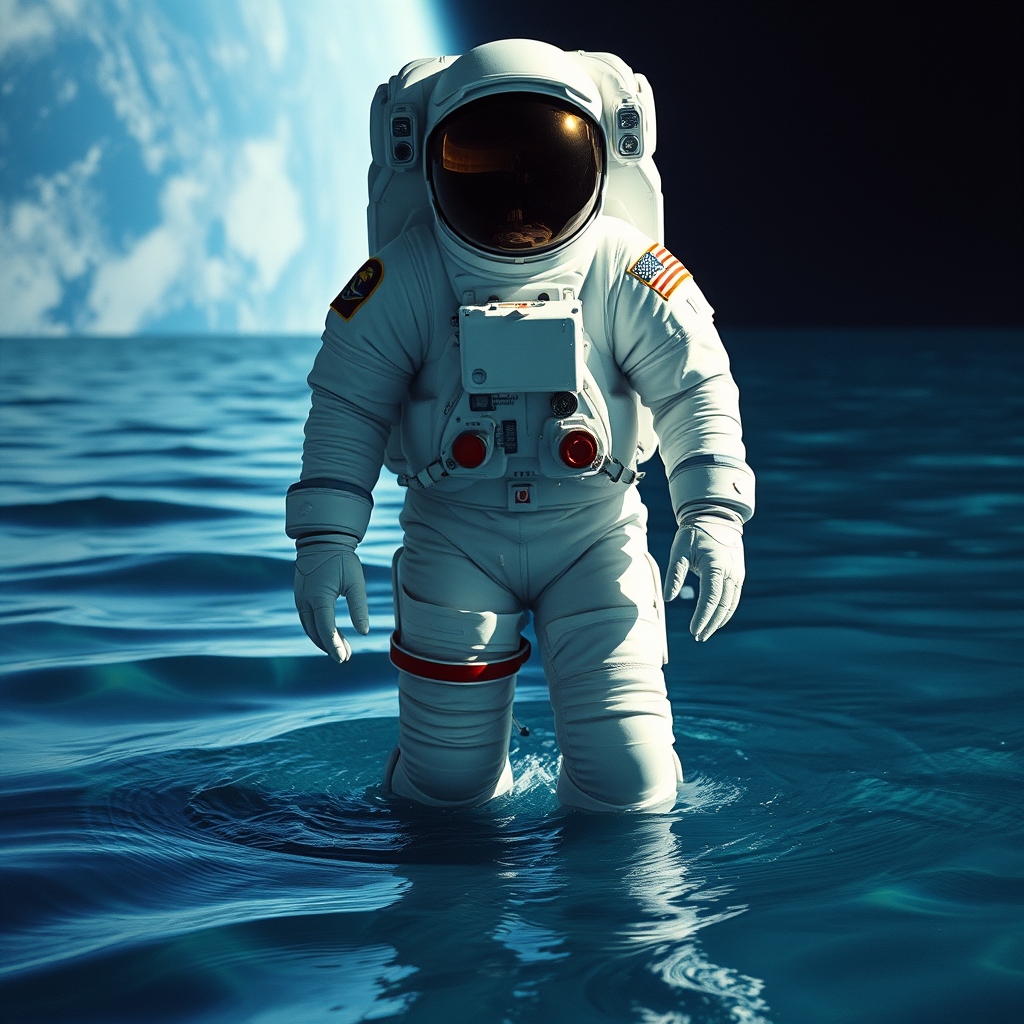

In [6]:
xl_output = pipeline(
    prompt=["An astronaut stands knee-deep in the sea"], 
    num_inference_steps=4,
    generator=torch.Generator(42)
)
xl_output[0][0]

Pre-compiled engines support following image shapes: 512x512, 768x768, 1024x1024.

Let's test image of shape 512x512

100%|██████████| 4/4 [00:01<00:00,  2.68it/s]


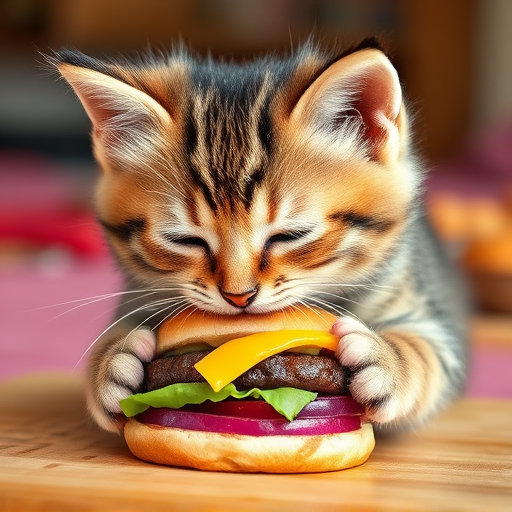

In [7]:
pipeline(
    prompt=["Kitten eating a burger"], 
    height=512, 
    width=512, 
    num_inference_steps=4
)[0][0]

Engines also support batched versions. Batch sizes 1-4 are available.

Below we run generation for batch of 4 images:

100%|██████████| 4/4 [00:02<00:00,  1.99it/s]


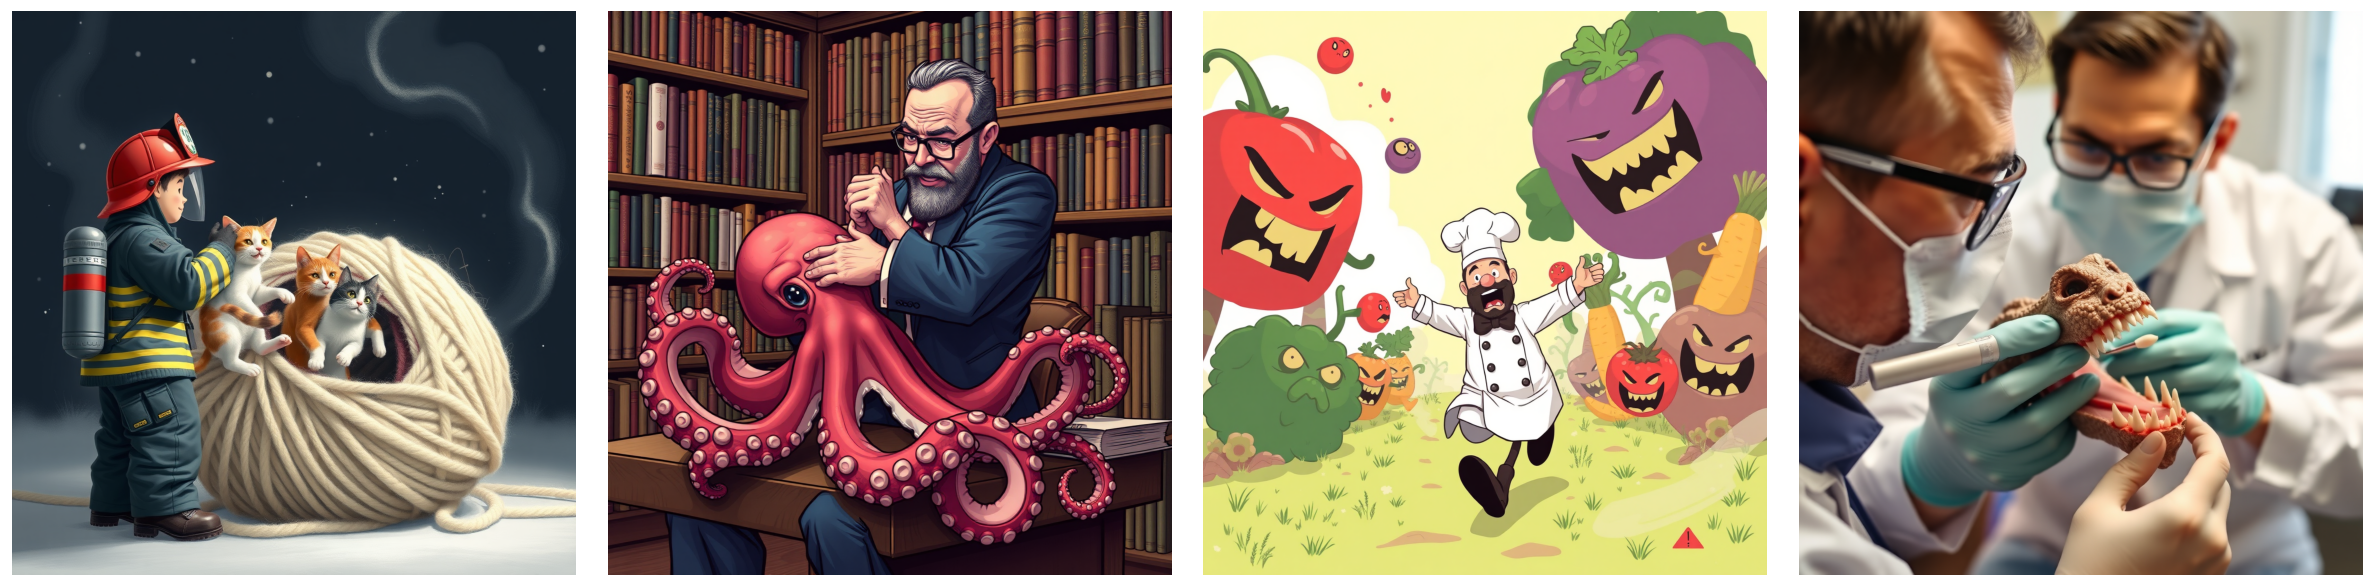

In [8]:
prompts = [
    "Firefighter rescuing cats from a giant yarn ball",
    "Librarian wrestling an octopus in a bookstore",
    "Chef being chased by giant angry vegetables",
    "Dentist examining a dragon's teeth",
]

output = pipeline(
    prompt=prompts,
    height=1024,
    width=1024,
    num_inference_steps=4,
    generator=torch.Generator(device=device).manual_seed(7)
)

# Display generated images
images = output[0]
plt.figure(figsize=(20, 5))

for i, image in enumerate(images):
    plt.subplot(1, 4, i+1)
    plt.imshow(image)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Benchmark inference time

Let's benchmark inference time and memory usage of the image generation pipeline.

To measure max memory usage we will use `pynvml` lib

In [9]:
import pynvml


def monitor_gpu_memory(queue, running_flag):
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)  # Assuming GPU 0
    max_memory_usage = 0

    try:
        while running_flag.value:
            info = pynvml.nvmlDeviceGetMemoryInfo(handle)
            memory_usage = info.used / (1024 * 1024)  # Convert to MiB
            max_memory_usage = max(max_memory_usage, memory_usage)
    finally:
        pynvml.nvmlShutdown()
        queue.put(max_memory_usage)

When benchmarking inference time, we perform warm-up calls and multiple repetitions to calculate average execution time, while ensuring proper CUDA synchronization.

In [10]:
import timeit

def benchmark_time(pipeline, prompt, number=3, repeat=3, **kwargs):
    run_func = lambda: pipeline(prompt=prompt, **kwargs)
    run_func()
    with torch.no_grad():
        runs = timeit.repeat(
            run_func,
            number=number,
            repeat=repeat,
            setup="import torch; torch.cuda.synchronize()",
        )
    return min(runs) / number

Benchmarks results for `XL` model with different batch sizes:

| Batch size | Inference time (sec) | Max memory usage (GB) |
|------------|----------------------|-----------------------|
| 1          | 0.70255              | 50.2                  |
| 4          | 2.723                | 67.9                  |


### Using compressed model

Remove previous model and clear memory

In [11]:
import gc
del pipeline
torch.cuda.empty_cache()
gc.collect();

Set `mode='S'` to load the fastest model variant.

In [12]:
mode_name = "black-forest-labs/FLUX.1-schnell"
device = torch.device("cuda")
pipeline = DiffusionPipeline.from_pretrained(
    mode_name,
    torch_dtype=torch.bfloat16,
    cache_dir="/mount/huggingface_cache",
    mode="S"
)
pipeline.to(device);

Fetching elastic checkpoint: 100%|██████████| 60/60 [00:00<00:00, 11202.24it/s]


Let's generate the same image with compressed model and compare it with original one.

100%|██████████| 4/4 [00:00<00:00, 25.67it/s]


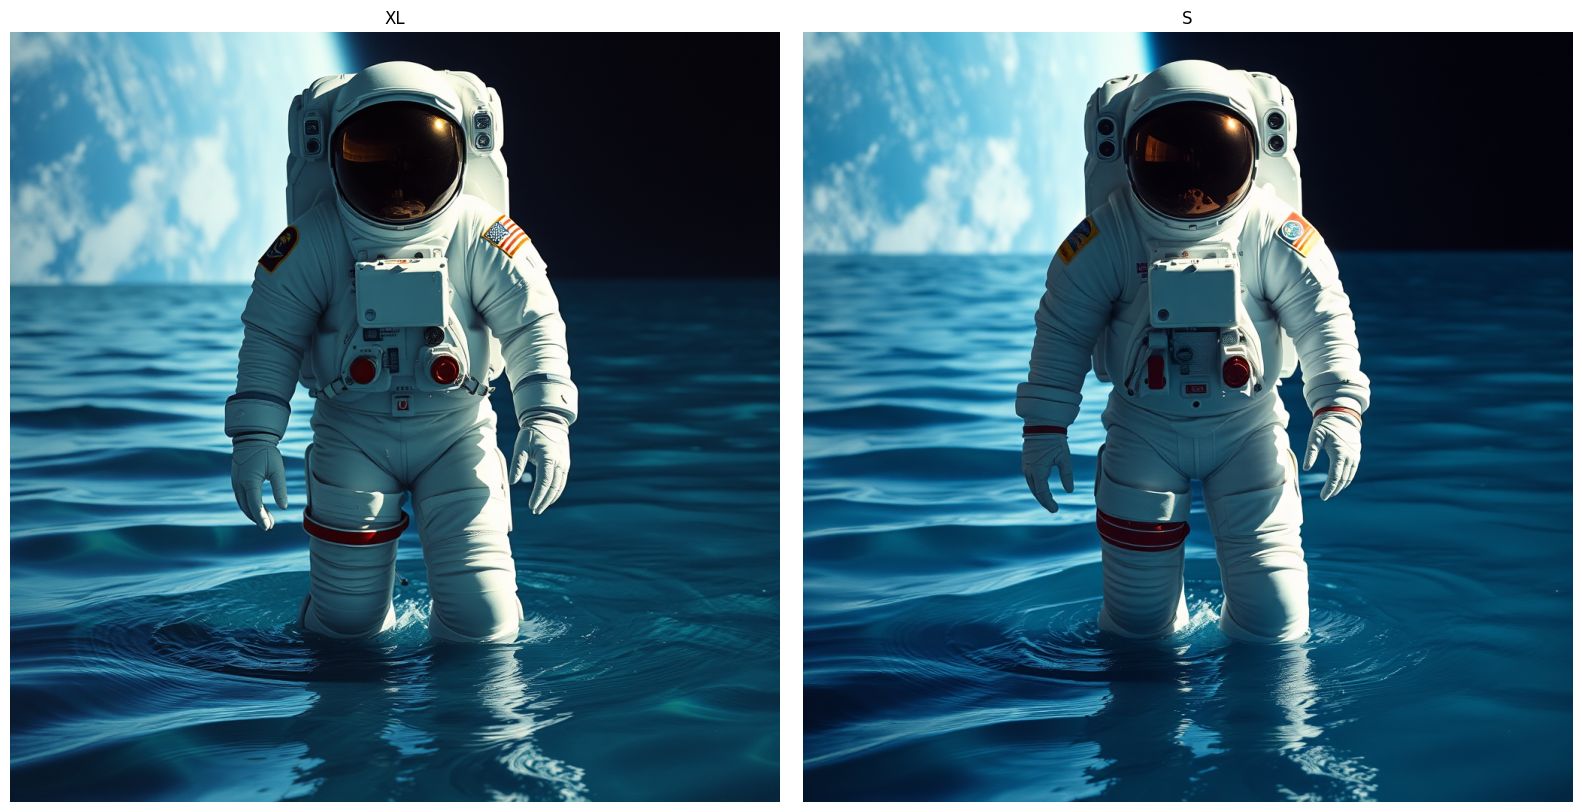

In [13]:
s_output = pipeline(
    prompt=["An astronaut stands knee-deep in the sea"],
    num_inference_steps=4,
    generator=torch.Generator(42)
)

plt.figure(figsize=(16, 8))

for i, image in enumerate([xl_output[0][0], s_output[0][0]]):
    plt.subplot(1, 2, i+1)
    plt.imshow(image)
    plt.title(["XL", "S"][i])
    plt.axis('off')
plt.tight_layout()
plt.show()

Benchmarks results for S model:

| Batch size | Inference time (sec) | Max memory usage (GB) |
|------------|----------------------|-----------------------|
| 1          | 0.4983               | 32.8                  |
| 4          | 1.9589               | 50.5                  |
